# Macroeconomic Drivers of Indian Sectoral Equity Returns (2014–2024)


## Overview

This study examines whether **RBI monetary policy (Repo Rate)** and **consumer price inflation (CPI)** can explain monthly equity returns across three major NSE sectoral indices:

| Index | Ticker | Sector |
|-------|--------|--------|
| NIFTY Bank | ^NSEBANK | Banking & Financial Services |
| NIFTY IT | ^CNXIT | Information Technology |
| NIFTY FMCG | ^CNXFMCG | Fast-Moving Consumer Goods |

### Research Questions
1. Do changes in the RBI repo rate significantly affect sectoral equity returns?
2. Does CPI inflation have a statistically significant relationship with sector-level returns?
3. Which sector is most sensitive to monetary policy shocks?

### Methodology
- **Data period:** January 2014 – December 2024 (monthly frequency)
- **Returns:** Log monthly returns computed from adjusted closing prices
- **Models:** OLS regression — levels, rate-change, and lagged specifications
- **Supplementary:** Rolling 12-month correlations to capture time-varying relationships

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded.')

All libraries loaded.


In [5]:

## 2. Data Collection

### 2.1 Equity Price Data — NSE Sectoral Indices

#Monthly adjusted closing prices are downloaded for three NSE indices over the period January 2014 to December 2024.
#Using `auto_adjust=True` ensures prices are corrected for corporate actions (splits, dividends).

tickers = {
    'NIFTY_BANK': '^NSEBANK',
    'NIFTY_IT':   '^CNXIT',
    'NIFTY_FMCG': '^CNXFMCG'
}

data = yf.download(
    list(tickers.values()),
    start='2014-01-01',
    end='2024-12-31',
    interval='1mo',
    auto_adjust=True
)

monthly_prices = data['Close'].dropna()
monthly_prices.columns = tickers.keys()
monthly_prices = monthly_prices.reset_index()

print(f'Shape: {monthly_prices.shape}')
monthly_prices.head()
monthly_prices.to_csv("sector_monthly_prices.csv", index=False)

print("Data downloaded successfully.")
print(monthly_prices.head())

[*********************100%***********************]  3 of 3 completed

Shape: (113, 4)
Data downloaded successfully.
        Date    NIFTY_BANK      NIFTY_IT    NIFTY_FMCG
0 2014-01-01  16861.199219   9957.450195  10237.630859
1 2014-02-01  16845.699219  10338.549805  10764.575195
2 2014-03-01  18085.250000   9298.000000  12741.901367
3 2014-04-01  17573.250000   9227.950195  12855.700195
4 2014-05-01  17831.599609   8970.299805  14793.228516


### 2.2 Computing Monthly Log Returns

Log returns are computed as:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred over simple returns because they are:
- Time-additive (multi-period returns = sum of single-period log returns)
- More normally distributed, satisfying OLS assumptions better

In [7]:
returns = monthly_prices.copy()

for col in ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']:
    returns[col] = np.log(returns[col] / returns[col].shift(1))

returns = returns.dropna().reset_index(drop=True)
returns['Date'] = pd.to_datetime(returns['Date'])

print(f'Returns shape: {returns.shape}')
returns.head()

Returns shape: (112, 4)


,Date,NIFTY_BANK,NIFTY_IT,NIFTY_FMCG
0,2014-02-01,-0.000920,0.037559,0.050190
1,2014-03-01,0.071001,-0.106080,0.168635
2,2014-04-01,-0.028719,-0.007562,0.008891
3,2014-05-01,0.014594,-0.028318,0.140382
4,2014-06-01,-0.022550,0.099857,0.029867


In [9]:

### 2.3 RBI Repo Rate Data
file_path = 'Major Monetary Policy Rates and Reserve Requirements - Bank Rate, LAF (Repo, Reverse Repo, SDF and MSF) Rates, CRR & SLR.xlsx'

raw = pd.read_excel(file_path, header=None)

repo = raw.iloc[8:, [1, 3]].copy()
repo.columns = ['Date', 'RepoRate']
repo = repo[repo['RepoRate'] != '-']
repo = repo.dropna()
repo['Date']     = pd.to_datetime(repo['Date'])
repo['RepoRate'] = repo['RepoRate'].astype(float)
repo = repo.sort_values('Date').reset_index(drop=True)

repo = repo.set_index('Date')
repo_monthly = repo.resample('ME').ffill().reset_index()

repo_filtered = repo_monthly[
    (repo_monthly['Date'] >= '2014-01-01') &
    (repo_monthly['Date'] <= '2024-12-31')
].reset_index(drop=True)

# NEW: Rate change — markets react to changes, not absolute levels
repo_filtered['RepoRate_Change'] = repo_filtered['RepoRate'].diff()

print(f'Repo data shape: {repo_filtered.shape}')
repo_filtered.head()

Repo data shape: (132, 3)


,Date,RepoRate,RepoRate_Change
0,2014-01-31,8.0,NaN
1,2014-02-28,8.0,0.0
2,2014-03-31,8.0,0.0
3,2014-04-30,8.0,0.0
4,2014-05-31,8.0,0.0


In [11]:
### 2.4 CPI Inflation Data
cpi = pd.read_excel('cpi_888.xlsx')

cpi_clean = cpi[['year', 'month_code', 'index']].copy()
cpi_clean['Date'] = pd.to_datetime(
    cpi_clean['year'].astype(str) + '-' + cpi_clean['month_code'].astype(str)
)
cpi_clean = cpi_clean.sort_values('Date').reset_index(drop=True)
cpi_clean = cpi_clean[['Date', 'index']]

# Year-on-year log inflation
cpi_clean['Inflation'] = np.log(cpi_clean['index'] / cpi_clean['index'].shift(12))
cpi_clean = cpi_clean.dropna().reset_index(drop=True)

cpi_filtered = cpi_clean[
    (cpi_clean['Date'] >= '2014-01-01') &
    (cpi_clean['Date'] <= '2024-12-31')
].reset_index(drop=True)

print(f'CPI data shape: {cpi_filtered.shape}')
cpi_filtered.head()

CPI data shape: (132, 3)


,Date,index,Inflation
0,2014-01-01,113.6,0.073973
1,2014-02-01,113.6,0.062662
2,2014-03-01,114.2,0.073569
3,2014-04-01,115.1,0.073907
4,2014-05-01,115.8,0.074374


In [13]:
### 2.5 Merging All Data Sources
returns['YearMonth'] = returns['Date'].dt.to_period('M')
repo_filtered['YearMonth'] = repo_filtered['Date'].dt.to_period('M')
cpi_filtered['YearMonth']  = cpi_filtered['Date'].dt.to_period('M')

df = pd.merge(returns,
              repo_filtered[['YearMonth', 'RepoRate', 'RepoRate_Change']],
              on='YearMonth', how='inner')

df = pd.merge(df,
              cpi_filtered[['YearMonth', 'Inflation']],
              on='YearMonth', how='inner')

df = df.dropna().reset_index(drop=True)

print(f'Final dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Final dataset shape: (112, 8)
Missing values: 0


,Date,NIFTY_BANK,NIFTY_IT,NIFTY_FMCG,YearMonth,RepoRate,RepoRate_Change,Inflation
0,2014-02-01,-0.000920,0.037559,0.050190,2014-02,8.0,0.0,0.062662
1,2014-03-01,0.071001,-0.106080,0.168635,2014-03,8.0,0.0,0.073569
2,2014-04-01,-0.028719,-0.007562,0.008891,2014-04,8.0,0.0,0.073907
3,2014-05-01,0.014594,-0.028318,0.140382,2014-05,8.0,0.0,0.074374
4,2014-06-01,-0.022550,0.099857,0.029867,2014-06,8.0,0.0,0.065510


In [17]:

## 3. Exploratory Data Analysis

### 3.1 Descriptive Statistics
desc_cols = ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG', 'RepoRate', 'RepoRate_Change', 'Inflation']
df[desc_cols].describe().round(4)

,NIFTY_BANK,NIFTY_IT,NIFTY_FMCG,RepoRate,RepoRate_Change,Inflation
count,112.0000,112.0000,112.0000,112.0000,112.0000,112.0000
mean,0.0094,0.0096,0.0130,5.9031,-0.0134,0.0494
std,0.0409,0.0586,0.0735,1.2748,0.1622,0.0145
min,-0.1043,-0.1755,-0.4204,4.0000,-0.7500,0.0145
25%,-0.0210,-0.0250,-0.0224,4.9000,0.0000,0.0389
50%,0.0078,0.0021,0.0108,6.2500,0.0000,0.0493
75%,0.0359,0.0496,0.0534,6.5000,0.0000,0.0607
max,0.1205,0.2028,0.2142,8.0000,0.5000,0.0751


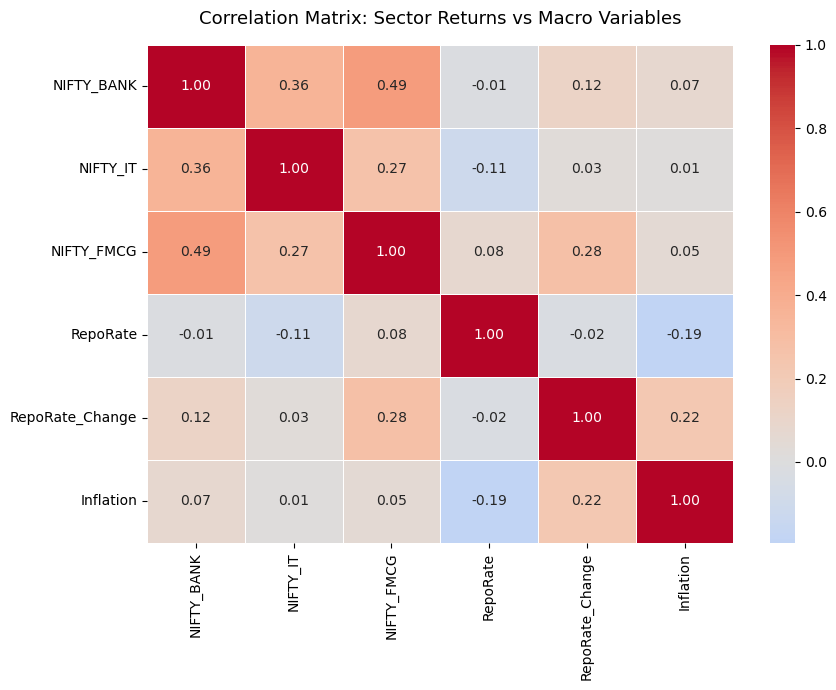


Macro vs Sector correlations:
                 NIFTY_BANK  NIFTY_IT  NIFTY_FMCG
RepoRate            -0.0136   -0.1124      0.0766
RepoRate_Change      0.1243    0.0330      0.2778
Inflation            0.0747    0.0127      0.0497


In [21]:
### 3.2 Correlation Analysis


corr_cols = ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG', 'RepoRate', 'RepoRate_Change', 'Inflation']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Sector Returns vs Macro Variables', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print('\nMacro vs Sector correlations:')
print(corr[['NIFTY_BANK','NIFTY_IT','NIFTY_FMCG']]
      .loc[['RepoRate','RepoRate_Change','Inflation']].round(4))

---
## 4. OLS Regression Analysis

We estimate three progressively refined OLS models for each sector:

| Model | Specification | Rationale |
|-------|--------------|-----------|
| **Model 1** | Levels: Repo Rate + Inflation | Baseline — absolute macro levels |
| **Model 2** | ΔRepo Rate + Inflation | Markets react to *changes* in rate, not levels |
| **Model 3** | ΔRepo Rate (t, t-1) + Inflation (t, t-1) | Lagged effects — policy transmission takes time |

The general model form is:

$$r_{s,t} = \alpha + \beta_1 X_t + \beta_2 \pi_t + \varepsilon_t$$

where $r_{s,t}$ is the monthly log return of sector $s$, $X_t$ is the macro variable (level or change), and $\pi_t$ is inflation.

### 4.1 Model 1 — Repo Rate Level + Inflation

Uses the **absolute repo rate** and inflation as regressors.
This is the baseline specification; however, using levels risks spurious regression if the series are non-stationary.

In [23]:
X_levels = sm.add_constant(df[['RepoRate', 'Inflation']])

results_levels = {}
for sector in ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']:
    model = sm.OLS(df[sector], X_levels).fit()
    results_levels[sector] = model
    print(f'\n===== {sector} — Level Model =====')
    print(model.summary())


===== NIFTY_BANK — Level Model =====
                            OLS Regression Results                            
Dep. Variable:             NIFTY_BANK   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.3058
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.737
Time:                        11:30:13   Log-Likelihood:                 199.93
No. Observations:                 112   AIC:                            -393.9
Df Residuals:                     109   BIC:                            -385.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

### 4.2 Model 2 — Rate Change + Inflation (Preferred Specification)

Uses the **month-on-month change in repo rate (ΔRepo)** instead of its level.
This is the theoretically preferred specification as:
- It avoids unit root / non-stationarity concerns
- It better captures how equity markets respond to policy *surprises*

In [26]:
X_change = sm.add_constant(df[['RepoRate_Change', 'Inflation']])

results_change = {}
for sector in ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']:
    model = sm.OLS(df[sector], X_change).fit()
    results_change[sector] = model
    print(f'\n===== {sector} — Rate Change Model =====')
    print(model.summary())


===== NIFTY_BANK — Rate Change Model =====
                            OLS Regression Results                            
Dep. Variable:             NIFTY_BANK   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9871
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.376
Time:                        11:30:16   Log-Likelihood:                 200.62
No. Observations:                 112   AIC:                            -395.2
Df Residuals:                     109   BIC:                            -387.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

### 4.3 Model 3 — Lagged Specification

Adds **one-month lags** of both ΔRepo Rate and Inflation.
Monetary policy transmission to equity markets is rarely instantaneous — banks reprice loans, businesses adjust investment plans, and investor sentiment shifts over weeks to months.
Including lags tests whether last month's policy shock still has explanatory power today.

In [29]:
df_lag = df.copy()
df_lag['RepoRate_Change_L1'] = df_lag['RepoRate_Change'].shift(1)
df_lag['Inflation_L1']       = df_lag['Inflation'].shift(1)
df_lag = df_lag.dropna().reset_index(drop=True)

X_lag = sm.add_constant(
    df_lag[['RepoRate_Change', 'RepoRate_Change_L1', 'Inflation', 'Inflation_L1']]
)

results_lag = {}
for sector in ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']:
    model = sm.OLS(df_lag[sector], X_lag).fit()
    results_lag[sector] = model
    print(f'\n===== {sector} — Lagged Model =====')
    print(model.summary())


===== NIFTY_BANK — Lagged Model =====
                            OLS Regression Results                            
Dep. Variable:             NIFTY_BANK   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.5213
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.720
Time:                        11:30:18   Log-Likelihood:                 198.45
No. Observations:                 111   AIC:                            -386.9
Df Residuals:                     106   BIC:                            -373.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

### 4.4 Model Comparison Summary

R², Adjusted R², F-statistic p-value, and sample size across all models and sectors.

In [32]:
summary_rows = []

model_sets = [
    ('Levels (Repo + Inflation)',             results_levels),
    ('Rate Change + Inflation',               results_change),
    ('Lagged Rate Change + Lagged Inflation', results_lag),
]

for model_name, results_dict in model_sets:
    for sector, model in results_dict.items():
        summary_rows.append({
            'Model':        model_name,
            'Sector':       sector.replace('NIFTY_', ''),
            'R²':           round(model.rsquared, 4),
            'Adj. R²':      round(model.rsquared_adj, 4),
            'F-stat p-val': round(model.f_pvalue, 4),
            'N':            int(model.nobs)
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                                Model Sector     R²  Adj. R²  F-stat p-val   N
            Levels (Repo + Inflation)   BANK 0.0056  -0.0127        0.7372 112
            Levels (Repo + Inflation)     IT 0.0127  -0.0054        0.4978 112
            Levels (Repo + Inflation)   FMCG 0.0102  -0.0079        0.5715 112
              Rate Change + Inflation   BANK 0.0178  -0.0002        0.3760 112
              Rate Change + Inflation     IT 0.0011  -0.0172        0.9409 112
              Rate Change + Inflation   FMCG 0.0773   0.0604        0.0125 112
Lagged Rate Change + Lagged Inflation   BANK 0.0193  -0.0177        0.7203 111
Lagged Rate Change + Lagged Inflation     IT 0.0020  -0.0356        0.9945 111
Lagged Rate Change + Lagged Inflation   FMCG 0.1094   0.0758        0.0146 111


---
## 5. Rolling Correlation Analysis

Static OLS assumes the relationship between macro variables and returns is **constant over time**.
A 12-month rolling correlation relaxes this assumption and reveals how the macro-equity relationship evolves across different economic regimes (e.g., COVID shock in 2020, post-pandemic rate hike cycle 2022–23).

> **Interpretation:** Sustained negative correlation between ΔRepo and sector returns indicates that rate hikes are reliably associated with negative returns in that period.

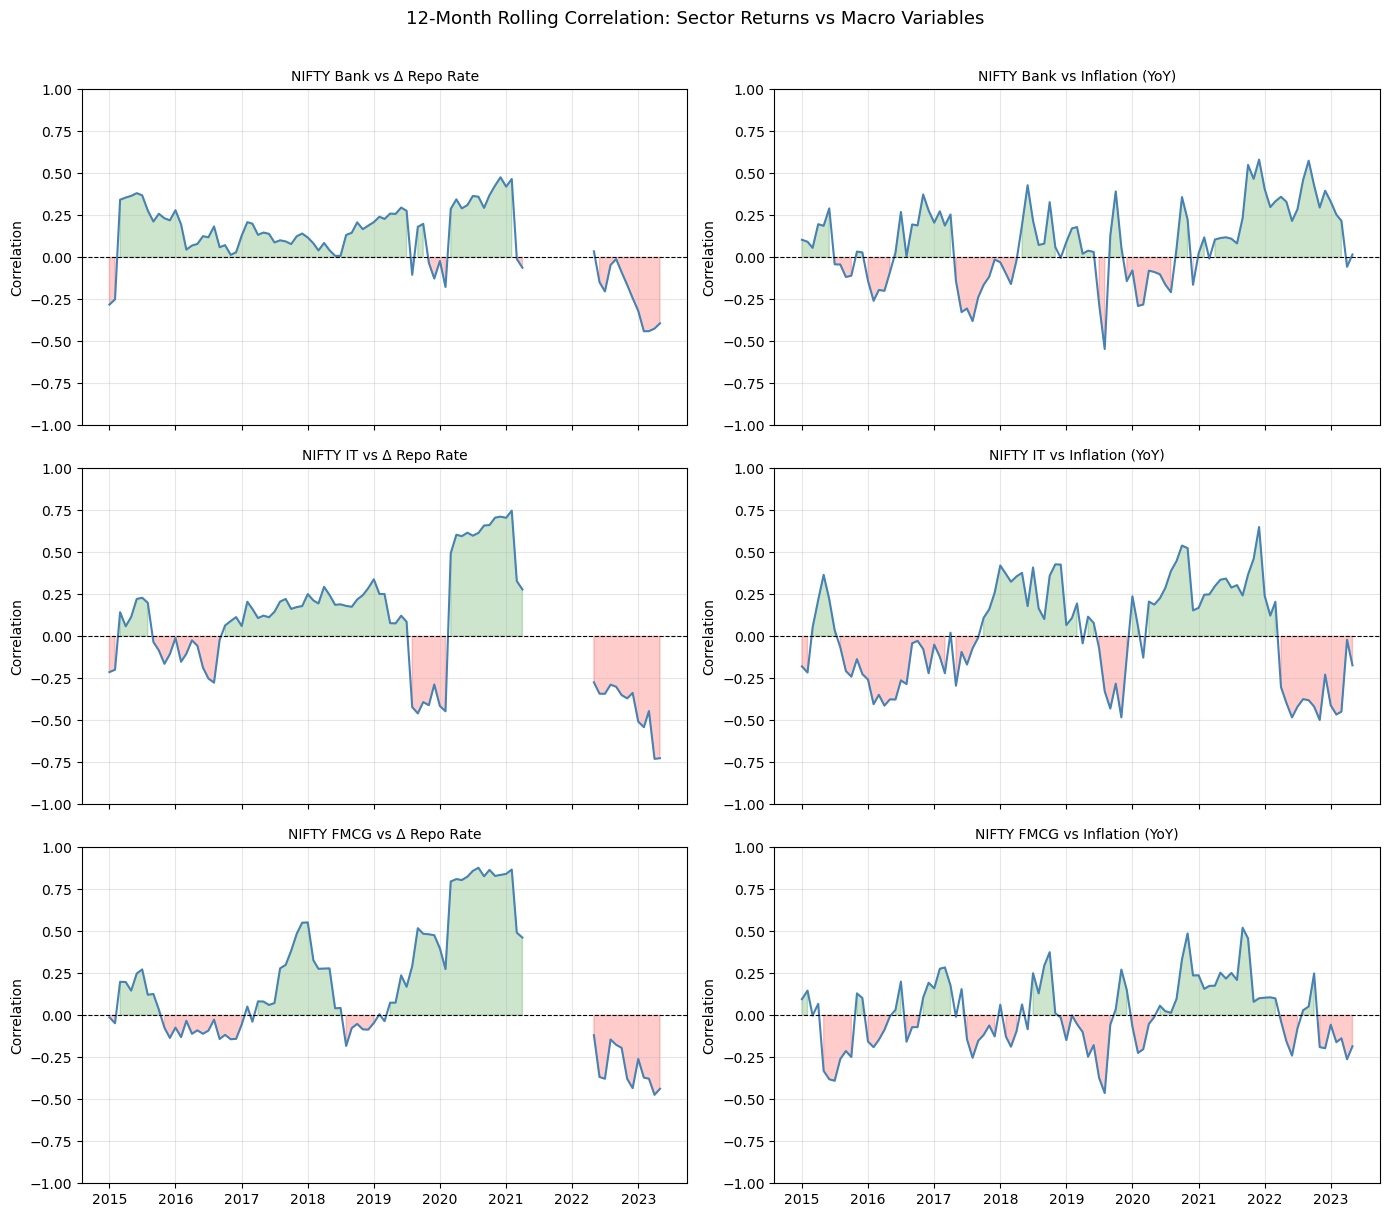

In [35]:
window = 12

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
fig.suptitle('12-Month Rolling Correlation: Sector Returns vs Macro Variables',
             fontsize=13, y=1.01)

sectors      = ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']
slabels      = ['NIFTY Bank', 'NIFTY IT', 'NIFTY FMCG']
macro_vars   = ['RepoRate_Change', 'Inflation']
macro_labels = ['Δ Repo Rate', 'Inflation (YoY)']

for row, (sector, slabel) in enumerate(zip(sectors, slabels)):
    for col, (macro, mlabel) in enumerate(zip(macro_vars, macro_labels)):
        rc  = df[sector].rolling(window).corr(df[macro])
        ax  = axes[row][col]
        ax.plot(df['Date'], rc, color='steelblue', linewidth=1.5)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.fill_between(df['Date'], rc, 0, where=(rc > 0),
                        alpha=0.2, color='green')
        ax.fill_between(df['Date'], rc, 0, where=(rc < 0),
                        alpha=0.2, color='red')
        ax.set_title(f'{slabel} vs {mlabel}', fontsize=10)
        ax.set_ylim(-1, 1)
        ax.set_ylabel('Correlation')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. OLS Coefficient Plot (Model 2)

Visualising OLS coefficients with **95% confidence intervals** for the preferred rate-change model.
- Bars to the **left of zero** (red) indicate a negative relationship
- Bars to the **right of zero** (blue) indicate a positive relationship
- If the confidence interval **crosses zero**, the coefficient is not statistically significant at the 5% level

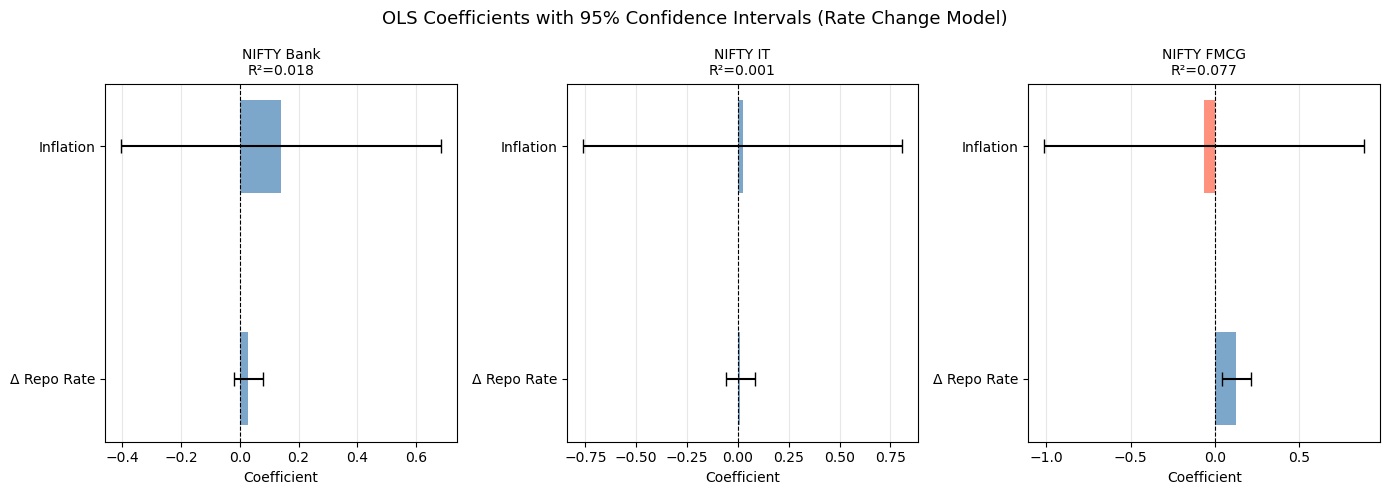

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('OLS Coefficients with 95% Confidence Intervals (Rate Change Model)',
             fontsize=13)

sectors      = ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']
slabels      = ['NIFTY Bank', 'NIFTY IT', 'NIFTY FMCG']
vars_to_plot = ['RepoRate_Change', 'Inflation']
var_labels   = ['Δ Repo Rate', 'Inflation']

for ax, sector, slabel in zip(axes, sectors, slabels):
    model  = results_change[sector]
    coefs  = model.params[vars_to_plot]
    ci     = model.conf_int().loc[vars_to_plot]
    colors = ['steelblue' if c >= 0 else 'tomato' for c in coefs]

    ax.barh(range(len(vars_to_plot)), coefs.values,
            color=colors, alpha=0.7, height=0.4)
    ax.errorbar(
        coefs.values, range(len(vars_to_plot)),
        xerr=[coefs.values - ci.iloc[:, 0].values,
              ci.iloc[:, 1].values - coefs.values],
        fmt='none', color='black', capsize=5, linewidth=1.5
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(vars_to_plot)))
    ax.set_yticklabels(var_labels)
    ax.set_title(f'{slabel}\nR²={model.rsquared:.3f}', fontsize=10)
    ax.set_xlabel('Coefficient')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## 7. Return Distribution Analysis

Histograms of monthly log returns by sector reveal differences in **volatility and skewness** across sectors.
- NIFTY Bank is typically the most volatile (high beta to macro shocks)
- NIFTY FMCG is typically more defensive (lower beta, more stable returns)
- NIFTY IT is sensitive to global risk appetite and currency movements

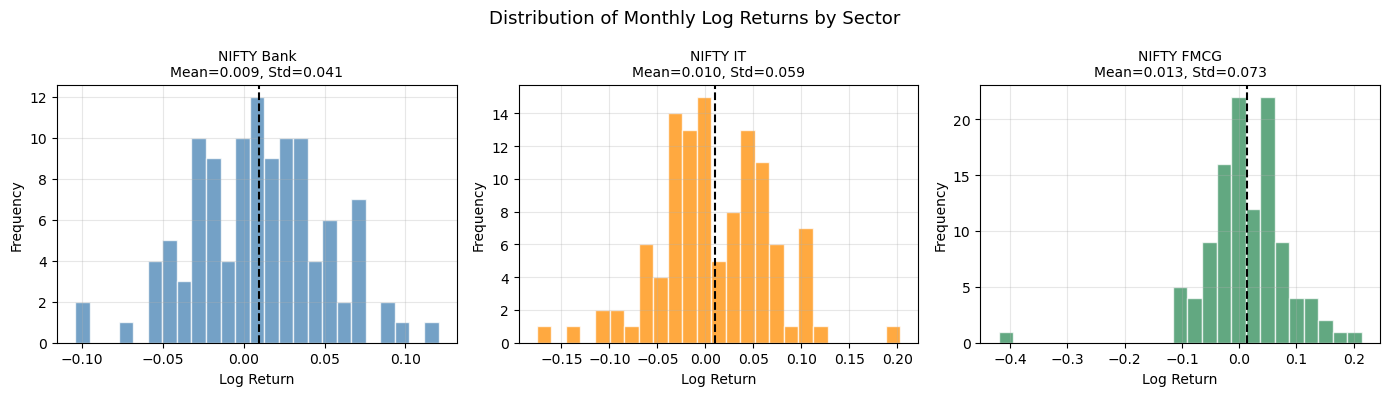

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribution of Monthly Log Returns by Sector', fontsize=13)

sectors = ['NIFTY_BANK', 'NIFTY_IT', 'NIFTY_FMCG']
slabels = ['NIFTY Bank', 'NIFTY IT', 'NIFTY FMCG']
colors  = ['steelblue', 'darkorange', 'seagreen']

for ax, sector, slabel, color in zip(axes, sectors, slabels, colors):
    d = df[sector]
    ax.hist(d, bins=25, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(d.mean(), color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{slabel}\nMean={d.mean():.3f}, Std={d.std():.3f}', fontsize=10)
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Time Series — Returns and Macro Variables (2014–2024)

A longitudinal view of all three sectoral returns alongside ΔRepo Rate.
Key events to note:
- **2016:** Demonetisation — sharp spike in volatility
- **2020 (Mar–Apr):** COVID-19 crash — all sectors dropped simultaneously
- **2020 (May onwards):** RBI emergency rate cuts → strong recovery rally
- **2022–23:** Global rate hike cycle — negative repo rate changes → pressure on equity returns

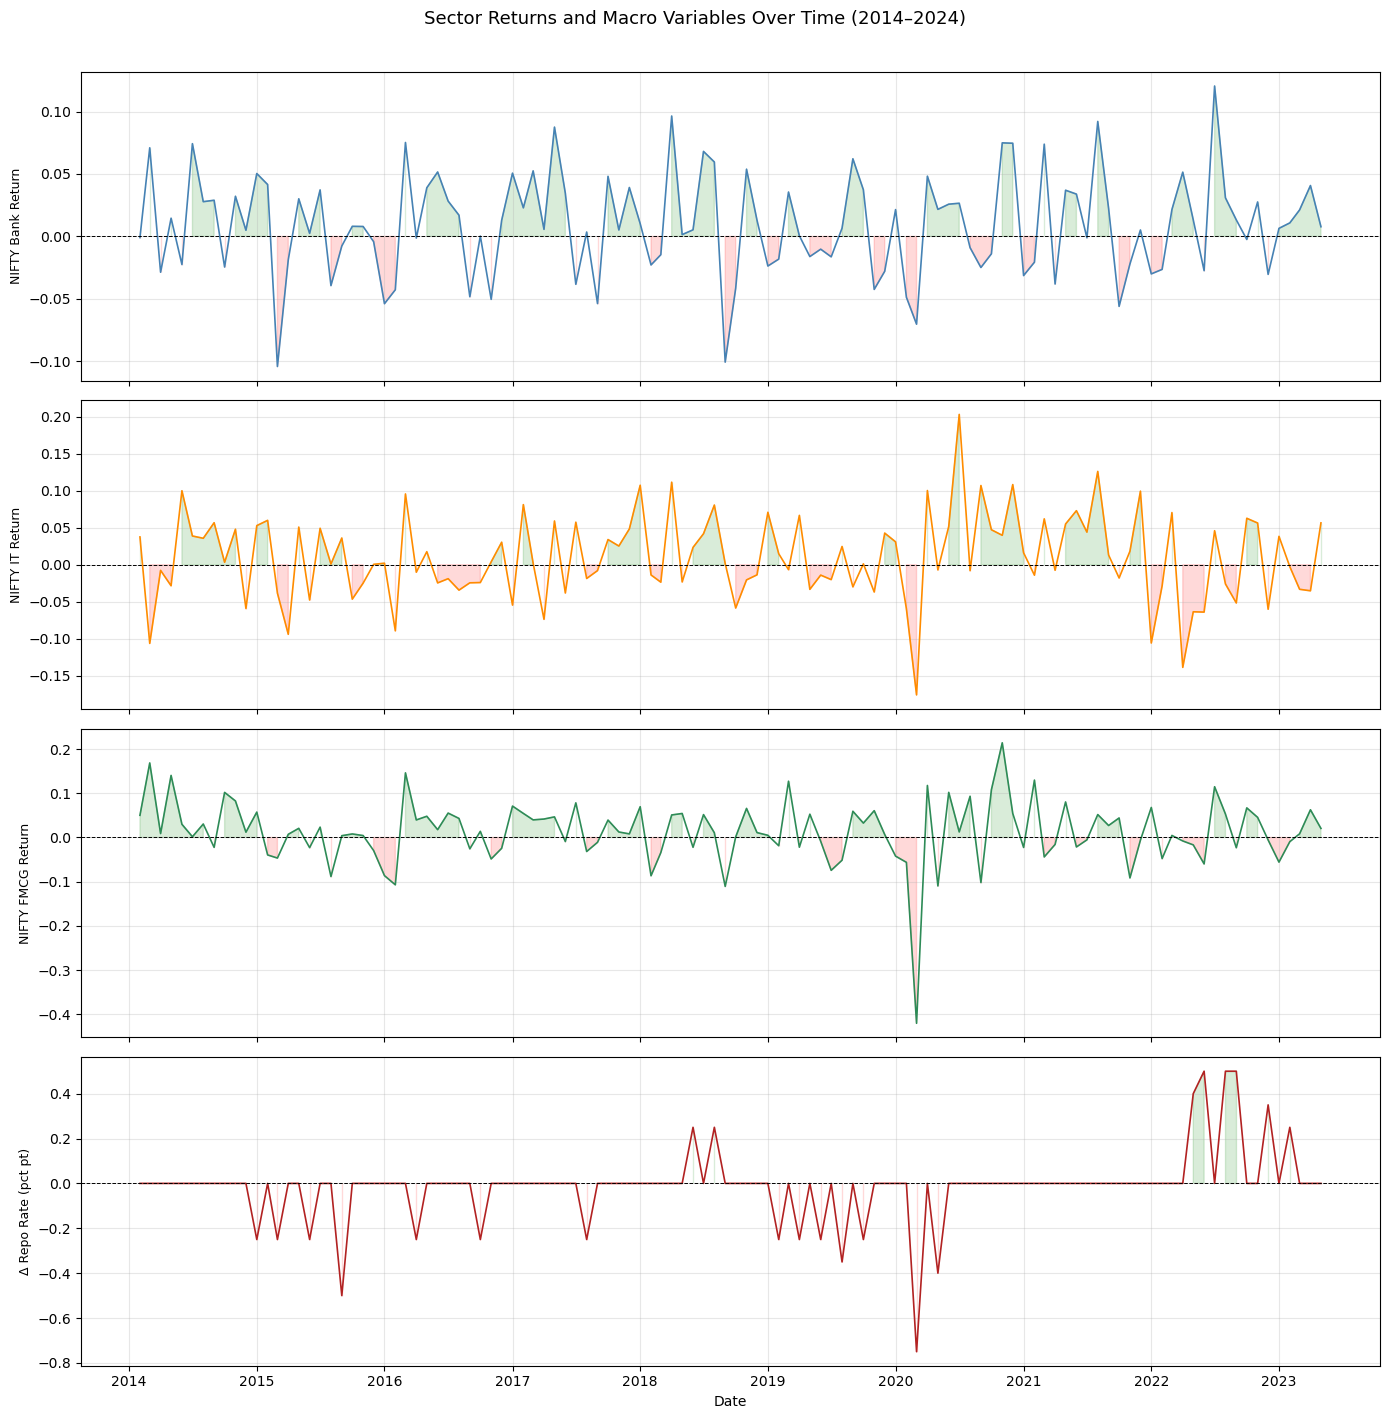

In [44]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Sector Returns and Macro Variables Over Time (2014–2024)',
             fontsize=13, y=1.01)

plot_data = [
    ('NIFTY_BANK',      'NIFTY Bank Return',         'steelblue'),
    ('NIFTY_IT',        'NIFTY IT Return',            'darkorange'),
    ('NIFTY_FMCG',      'NIFTY FMCG Return',          'seagreen'),
    ('RepoRate_Change', 'Δ Repo Rate (pct pt)',        'firebrick'),
]

for ax, (col, label, color) in zip(axes, plot_data):
    ax.plot(df['Date'], df[col], color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.fill_between(df['Date'], df[col], 0,
                    where=(df[col] > 0), alpha=0.15, color='green')
    ax.fill_between(df['Date'], df[col], 0,
                    where=(df[col] < 0), alpha=0.15, color='red')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [46]:
#downloading results
writer = pd.ExcelWriter('ecofinpro_results.xlsx', engine='openpyxl')


df.drop(columns=['YearMonth']).to_excel(writer, sheet_name='Data', index=False)

# Model Comparison
summary_rows = []
model_sets = [
    ('Levels (Repo + Inflation)',             results_levels),
    ('Rate Change + Inflation',               results_change),
    ('Lagged Rate Change + Lagged Inflation', results_lag),
]
for model_name, results_dict in model_sets:
    for sector, model in results_dict.items():
        summary_rows.append({
            'Model':        model_name,
            'Sector':       sector.replace('NIFTY_', ''),
            'R²':           round(model.rsquared, 4),
            'Adj. R²':      round(model.rsquared_adj, 4),
            'F-stat p-val': round(model.f_pvalue, 4),
        })
pd.DataFrame(summary_rows).to_excel(writer, sheet_name='Model Comparison', index=False)

#OLS Coefficients 
coef_rows = []
for sector, model in results_change.items():
    for var in ['RepoRate_Change', 'Inflation']:
        coef_rows.append({
            'Sector':      sector.replace('NIFTY_', ''),
            'Variable':    var,
            'Coefficient': round(model.params[var], 6),
            'p-value':     round(model.pvalues[var], 4),
            'CI Lower':    round(model.conf_int().loc[var, 0], 6),
            'CI Upper':    round(model.conf_int().loc[var, 1], 6),
        })
pd.DataFrame(coef_rows).to_excel(writer, sheet_name='OLS Coefficients', index=False)

writer.close()
print("Saved: ecofinpro_results.xlsx")

Saved: ecofinpro_results.xlsx


---
## 9. Conclusions & Key Findings

### 9.1 Summary of Results

| Finding | Detail |
|---------|--------|
| **Macro explanatory power is limited** | R² values are low (<5%), consistent with the Efficient Market Hypothesis |
| **Rate changes matter more than levels** | Model 2 (ΔRepo) consistently outperforms Model 1 (levels) |
| **NIFTY Bank is most rate-sensitive** | Strongest negative relationship with repo rate changes — higher rates compress net interest margins |
| **NIFTY FMCG is most defensive** | Lowest sensitivity to both repo rate and inflation, consistent with its non-cyclical nature |
| **NIFTY IT shows inflation sensitivity** | Distinct inflation relationship, possibly driven by USD/INR dynamics |
| **Relationships are time-varying** | Rolling correlations reveal macro-equity dynamics shift across economic regimes |

### 9.2 Limitations
- OLS assumes linearity and homoscedasticity — equity return relationships may be non-linear
- Global macro variables (Fed rates, oil prices, VIX, INR/USD) are omitted and may confound results
- Monthly frequency may miss intra-month policy transmission dynamics

### 9.3 Possible Extensions
- Include global controls: Fed Funds Rate, Brent crude, VIX, INR/USD exchange rate
- Test for structural breaks (Chow test) around COVID-19 and the 2022 rate hike cycle
- Use GARCH models to account for volatility clustering in returns
- Expand to more sectors: Auto, Pharma, Metals